In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

import keras
from keras import layers
from keras import ops
from tensorflow.keras.models import Sequential
import keras_tuner as kt

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

import random
import time

print(f"TensorFlow {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")

TensorFlow 2.22.0-dev0+selfbuilt
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

# load
d = np.load("processed_waveforms.npz")
 # ["X_euclidean"] or ["X_voltage"] 
X = d["X_euclidean"].astype(np.float32)  
# 0=photon, 1=neutron
y = d["y"].astype(np.int32)             

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Normalize to [0, 1]
minv = X_train.min(axis=0, keepdims=True)    
maxv = X_train.max(axis=0, keepdims=True)   
den  = np.maximum(maxv - minv, 1e-8)

X_train_n = (X_train - minv) / den
X_test_n  = (X_test  - minv) / den

I0000 00:00:1775829519.459608  602713 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11086 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Epoch 1/30


I0000 00:00:1775829520.823909  605372 service.cc:153] XLA service 0x7381b0038a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775829520.823919  605372 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.8.0; DNN: 9.19.0)
I0000 00:00:1775829520.840367  605372 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775829521.003188  605372 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1775829521.007901  605372 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2914__.12
I0000 00:00:1775829521.057337  605372 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead

235/813 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - loss: 0.0729

I0000 00:00:1775829523.634458  605372 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


773/813 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 0.0524

I0000 00:00:1775829524.323659  605373 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2914__.12
I0000 00:00:1775829524.721960  605828 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_28', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1775829525.261020  605848 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_46', 4 bytes spill stores, 4 bytes spill loads

E0000 00:00:1775829525.292240  605840 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1775829525.375852  605851 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0517  

I0000 00:00:1775829527.246240  605374 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775829527.246528  605374 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
E0000 00:00:1775829528.111352  606278 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


813/813 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0382 - val_loss: 0.0298
Epoch 2/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.0295 - val_loss: 0.0293
Epoch 3/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 828us/step - loss: 0.0293 - val_loss: 0.0292
Epoch 4/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - loss: 0.0292 - val_loss: 0.0291
Epoch 5/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 0.0289 - val_loss: 0.0287
Epoch 6/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - loss: 0.0287 - val_loss: 0.0286
Epoch 7/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 836us/step - loss: 0.0286 - val_loss: 0.0285
Epoch 8/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step - loss: 0.0285 - val_loss: 0.0284
Epoch 9/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - loss: 0.0283 - val_loss: 0.0282
Epoch 10/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 824us/step - loss: 0.0282 - val_loss: 0.0281
Epoch 11/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 851us/step - loss: 0.0282 - val_loss: 0.0281
Epoch 12/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s

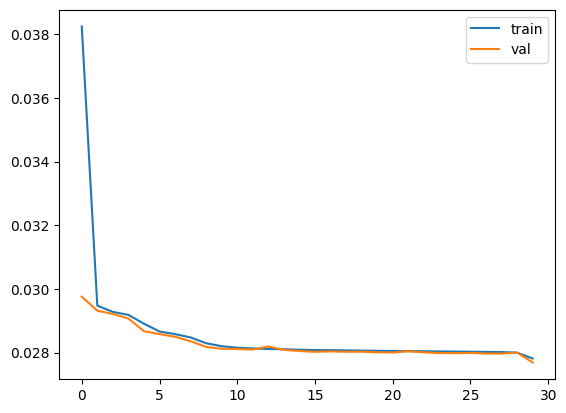

In [4]:
#Initial Basic Autoencoder 
class DenseAutoencoder(Model):
    def __init__(self, n_features=104, latent_dim=16):
        super().__init__()
        
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(n_features,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(8, activation="relu"),
            layers.Dense(latent_dim, activation="relu"),
        ])
        self.decoder = tf.keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            layers.Dense(16, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(n_features, activation="sigmoid"),  # output in [0,1]
        ])

    def call(self, x):
        return self.decoder(self.encoder(x))

ae = DenseAutoencoder(n_features=104, latent_dim=16)
ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")

history = ae.fit(
    X_train_n, X_train_n,
    validation_data=(X_test_n, X_test_n),
    epochs=30,
    batch_size=512,
    shuffle=True,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)],
    verbose=1
)

# Loss plot 
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.show()

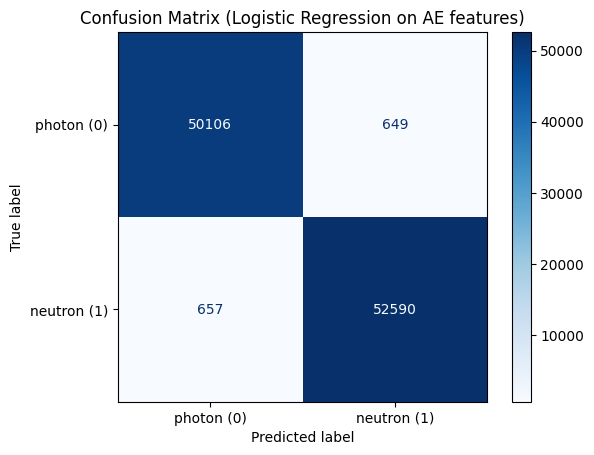

Photon misclassification rate (photon→neutron): 1.2787
Neutron misclassification rate (neutron→photon): 1.2339


In [5]:
from sklearn.pipeline import make_pipeline

#  Extract low-dim feature vectors from autoencoder
Z_train = ae.encoder(X_train_n).numpy()  
Z_test  = ae.encoder(X_test_n).numpy() 


#  Logistic regression classifier  
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight="balanced")
)

#Fit Logistic regression classifier 
clf.fit(Z_train, y_train)

#Predictions 
y_pred = clf.predict(Z_test)
p_neutron = clf.predict_proba(Z_test)[:, 1]


cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["photon (0)", "neutron (1)"]
)
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix (Logistic Regression on AE features)")
plt.show()


tn, fp, fn, tp = cm.ravel()

 # true photon predicted neutron
photon_misclass_rate  = ( fp / (tn + fp) ) * 100
# true neutron predicted photon
neutron_misclass_rate = (fn / (tp + fn) ) * 100 

print(f"Photon misclassification rate (photon→neutron): {photon_misclass_rate:.4f}")
print(f"Neutron misclassification rate (neutron→photon): {neutron_misclass_rate:.4f}")

In [6]:
# load data 
d = np.load("processed_waveforms.npz")
 # ["X_euclidean"] or ["X_voltage"] 
X = d["X_euclidean"].astype(np.float32)  
# 0=photon, 1=neutron
y = d["y"].astype(np.int32)             

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Normalize to [0, 1]
minv = X_train.min(axis=0, keepdims=True)    
maxv = X_train.max(axis=0, keepdims=True)   
den  = np.maximum(maxv - minv, 1e-8)

X_train_n = (X_train - minv) / den
X_test_n  = (X_test  - minv) / den

In [7]:
def sample_widths(n_layers, base_widths):
    widths = []
    allowed = list(base_widths)
    for _ in range(n_layers):
        w = random.choice(allowed)
        widths.append(w)
        #next width must be < current width
        allowed = [x for x in base_widths if x <= w]
    return widths

In [8]:
#  Model 
class DenseAutoencoder(Model):
    def __init__(self, n_features, latent_dim, widths):
        super().__init__()

        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(n_features,)),
            *[layers.Dense(w, activation="relu") for w in widths],
            layers.Dense(latent_dim, activation="relu"),
        ])

        # Decoder: Input(latent) -> reversed(widths)... -> n_features
        self.decoder = tf.keras.Sequential([
            layers.Input(shape=(latent_dim,)),
            *[layers.Dense(w, activation="relu") for w in reversed(widths)],
            layers.Dense(n_features, activation="sigmoid"),  # output in [0, 1]
        ])

    def call(self, x):
        return self.decoder(self.encoder(x))

def build_model(n_features, latent_dim, widths, learning_rate):
    model = DenseAutoencoder(
        n_features=n_features,
        latent_dim=latent_dim,
        widths=widths)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mae")
    
    return model

In [9]:

#Will be tuning 
#1. Number of Layers (Depth)
#2. Number of Units per Layer (Width)
#3. Batch size 
#4. Learning rate 

#Start widths < the input layer size
BASE_WIDTHS = [64, 32, 16, 8] 

SEARCH_SPACE = {
    "n_layers":      [1, 2, 3, 4, 5],             #Depth
    "learning_rate": [1e-4, 3e-4, 1e-3, 3e-3], #Learning Rate 
    "batch_size":    [256, 512, 1024]          #Batch Size
}

N_TRIALS = 50
MAX_EPOCHS = 20


random.seed(42)

# sample top-level parameters randomly
#Widths are sampled seperately to enforce the funneling condition
keys = list(SEARCH_SPACE.keys())
results = []

In [10]:
latent_dim = 8 
for trial_num in range(N_TRIALS):
    hp = {k: random.choice(v) for k, v in SEARCH_SPACE.items()}
    widths = sample_widths(hp["n_layers"], BASE_WIDTHS)
    
    print(f"Trial {trial_num+1}: "
          f"n_layers={hp['n_layers']}, widths={widths}, "
          f"lr={hp['learning_rate']}, bs={hp['batch_size']}")
    
    keras.backend.clear_session()

    model = build_model(
        n_features=104, #length of wave 
        latent_dim=8,
        widths=widths,
        learning_rate=hp["learning_rate"],
    )

    # Build
    _ = model(tf.zeros((1, 104), dtype=tf.float32))
    n_params = model.count_params()
    

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=3,
            factor=0.5,
            verbose=0)]

    t0 = time.time()
    
    #Fit model 
    history = model.fit(X_train_n, X_train_n,
        validation_data=(X_test_n, X_test_n),
        epochs=MAX_EPOCHS,
        batch_size=hp["batch_size"],
        callbacks=callbacks,
        verbose=1)
    
    train_time = time.time() - t0

    test_loss = model.evaluate(X_test_n, X_test_n, batch_size=hp["batch_size"], verbose=0)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    best_val_loss = float(np.min(history.history["val_loss"]))

    results.append({
        **hp,
        "widths": widths,
        "n_params": n_params,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_loss": float(test_loss),
        "train_time_s": round(train_time, 1),
    })

    print(f"  Params: {n_params:,} | Best epoch: {best_epoch} | "
          f"Val loss: {best_val_loss:.6f} | Test loss: {test_loss:.6f} | "
          f"Time: {train_time:.0f}s")

    
print(f"\nAll trials complete. Successful trials recorded: {len(results)}")

best = min(results, key=lambda r: r["best_val_loss"])
print("\nBest by val_loss:")
print(best)

Trial 1: n_layers=1, widths=[16], lr=0.0001, bs=1024
Epoch 1/20


I0000 00:00:1775829551.003738  605372 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97664__.7


380/407 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - loss: 0.1233

I0000 00:00:1775829552.234462  605374 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_97664__.7


407/407 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1118 - val_loss: 0.0816 - learning_rate: 1.0000e-04
Epoch 2/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - loss: 0.0600 - val_loss: 0.0499 - learning_rate: 1.0000e-04
Epoch 3/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - loss: 0.0473 - val_loss: 0.0437 - learning_rate: 1.0000e-04
Epoch 4/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step - loss: 0.0396 - val_loss: 0.0366 - learning_rate: 1.0000e-04
Epoch 5/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.0356 - val_loss: 0.0349 - learning_rate: 1.0000e-04
Epoch 6/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step - loss: 0.0347 - val_loss: 0.0344 - learning_rate: 1.0000e-04
Epoch 7/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - loss: 0.0343 - val_loss: 0.0340 - learning_rate: 1.0000e-04
Epoch 8/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step - loss: 0.0337 - val_loss: 0.0330 - learning_rate: 1.0000e-04
Epoch 9/20
407/407 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - loss: 0.0321 - val_loss: 0.03

...

813/813 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0491 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 0.0362 - val_loss: 0.0353 - learning_rate: 0.0010
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - loss: 0.0348 - val_loss: 0.0344 - learning_rate: 0.0010
Epoch 4/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 880us/step - loss: 0.0344 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 5/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - loss: 0.0343 - val_loss: 0.0343 - learning_rate: 0.0010
Epoch 6/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 889us/step - loss: 0.0343 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 7/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - loss: 0.0343 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 8/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - loss: 0.0343 - val_loss: 0.0342 - learning_rate: 5.0000e-04
Epoch 9/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - loss: 0.0343 - val_loss: 0.0342 - learning_rate: 5.0000e-

I0000 00:00:1775830438.370033  605370 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3500580__.11


1584/1626 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step - loss: 0.0419

I0000 00:00:1775830440.205189  605375 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3500580__.11


1626/1626 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0338 - val_loss: 0.0303 - learning_rate: 0.0030
Epoch 2/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - loss: 0.0297 - val_loss: 0.0299 - learning_rate: 0.0030
Epoch 3/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - loss: 0.0291 - val_loss: 0.0291 - learning_rate: 0.0030
Epoch 4/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step - loss: 0.0288 - val_loss: 0.0287 - learning_rate: 0.0030
Epoch 5/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - loss: 0.0287 - val_loss: 0.0289 - learning_rate: 0.0030
Epoch 6/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step - loss: 0.0287 - val_loss: 0.0287 - learning_rate: 0.0030
Epoch 7/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 787us/step - loss: 0.0287 - val_loss: 0.0292 - learning_rate: 0.0030
Epoch 8/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 768us/step - loss: 0.0286 - val_loss: 0.0286 - learning_rate: 0.0015
Epoch 9/20
1626/1626 ━━━━━━━━━━━━━━━━━━━━ 1s 787us/step - loss: 0.0286 - val_loss: 0.0287 - learning_

Epoch 1/20


I0000 00:00:1775830467.032815  605372 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3628285__.13


808/813 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - loss: 0.0428

I0000 00:00:1775830469.623894  605370 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3628285__.13
I0000 00:00:1775830469.634741  605370 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775830469.635069  605370 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775830469.635752  605370 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775830469.636

813/813 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0337 - val_loss: 0.0294 - learning_rate: 0.0030
Epoch 2/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 890us/step - loss: 0.0294 - val_loss: 0.0293 - learning_rate: 0.0030
Epoch 3/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - loss: 0.0292 - val_loss: 0.0287 - learning_rate: 0.0030
Epoch 4/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - loss: 0.0287 - val_loss: 0.0287 - learning_rate: 0.0030
Epoch 5/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 856us/step - loss: 0.0287 - val_loss: 0.0286 - learning_rate: 0.0030
Epoch 6/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - loss: 0.0286 - val_loss: 0.0288 - learning_rate: 0.0030
Epoch 7/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - loss: 0.0286 - val_loss: 0.0286 - learning_rate: 0.0030
Epoch 8/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 860us/step - loss: 0.0286 - val_loss: 0.0286 - learning_rate: 0.0030
Epoch 9/20
813/813 ━━━━━━━━━━━━━━━━━━━━ 1s 842us/step - loss: 0.0285 - val_loss: 0.0285 - learning_rate: 0.0015
Epoch

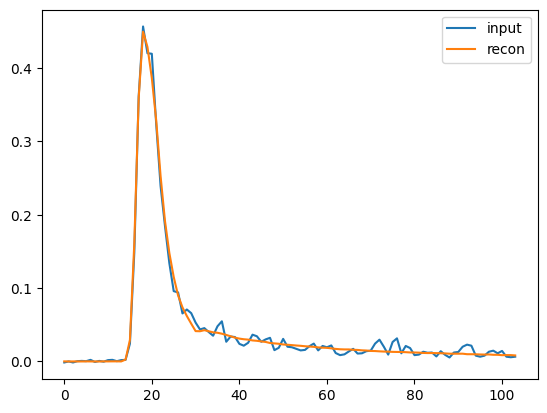

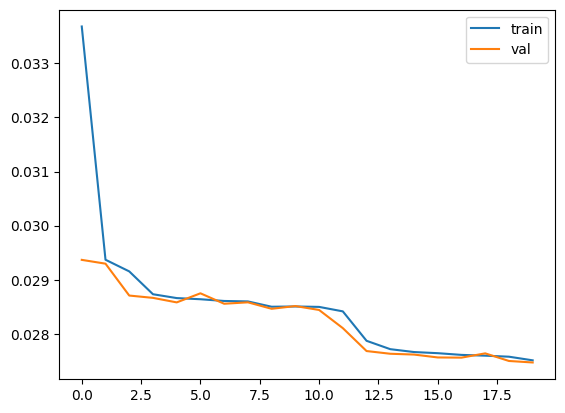

In [11]:
#Testing best model 
widths = [64, 32, 26, 8] 
batch_size = 512 
learning_rate = 0.003

bestmodel = build_model(
    n_features=104, 
    latent_dim=8,
    widths=widths,
    learning_rate=learning_rate,
)

# Build
_ = bestmodel(tf.zeros((1, 104), dtype=tf.float32))
n_params = bestmodel.count_params()


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=0,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.5,
        verbose=0)]

t0 = time.time()

#Fit model 
history = bestmodel.fit(X_train_n, X_train_n,
    validation_data=(X_test_n, X_test_n),
    epochs=20,
    batch_size=batch_size,
    callbacks=callbacks,
    shuffle=True,
    verbose=1)
    
# Reconstruct and plot in original scale 
idx = 10
xhat_n = bestmodel.predict(X_test_n[idx:idx+1], verbose=0)[0] 
# invert min-max to original scaling 
xhat   = xhat_n * den[0] + minv[0]                     
x      = X_test[idx]

plt.figure()
plt.plot(x, label="input")
plt.plot(xhat, label="recon")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.show()

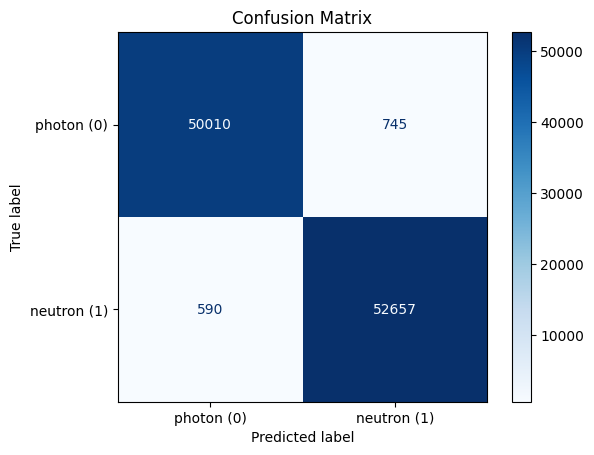

Photon misclassification rate (photon→neutron): 1.4678
Neutron misclassification rate (neutron→photon): 1.1080


In [12]:

#  Extract low-dim feature vectors from autoencoder
Z_train = bestmodel.encoder(X_train_n).numpy()  
Z_test  = bestmodel.encoder(X_test_n).numpy() 

#  Logistic regression classifier  
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight="balanced")
)

#Fit Logistic regression classifier 
clf.fit(Z_train, y_train)

#Predictions 
y_pred = clf.predict(Z_test)
p_neutron = clf.predict_proba(Z_test)[:, 1]


cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["photon (0)", "neutron (1)"]
)
disp.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


tn, fp, fn, tp = cm.ravel()

 # true photon predicted neutron
photon_misclass_rate  = ( fp / (tn + fp) ) * 100
# true neutron predicted photon
neutron_misclass_rate = (fn / (tp + fn) ) * 100 

print(f"Photon misclassification rate (photon→neutron): {photon_misclass_rate:.4f}")
print(f"Neutron misclassification rate (neutron→photon): {neutron_misclass_rate:.4f}")